<a href="https://colab.research.google.com/github/mediolanum1/dla/blob/2024/alex_net_for_cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import dataclasses
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from typing import Tuple, Union, List, Callable, Optional
import os, random
import numpy as np


import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # makes quality higher

import seaborn as sns
sns.set_style("whitegrid") # improves the quality of matplotlib


@dataclasses.dataclass
class TaskConfig:
  RANDOM_SEED: int = 1
  batch_size: int = 128
  learning_rate: float = 3e-4
  weight_decay: float = 1e-5
  num_classes: int = 10
  num_epochs: int = 10
  bidirectional: bool = False
  device: torch.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


### **Dataset**

In [ ]:
!wget https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz cifar-10-python.tar.gz # downloading cifar as cifar-10-python.tar.gz
!mkdir images # creating folder
!tar -C images -xvzf cifar-10-python.tar.gz 1> log # so here we extract archive into images folder -xvzf are flags, 1> log makes it so it doesnt print all files in terminal and instead prints in log file

--2024-10-27 15:17:35--  https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘cifar-10-python.tar.gz’

cifar-10-python.tar 100%[===================>] 162.60M  44.9MB/s    in 4.1s    

2024-10-27 15:17:40 (40.0 MB/s) - ‘cifar-10-python.tar.gz’ saved [170498071/170498071]

--2024-10-27 15:17:40--  http://cifar-10-python.tar.gz/
Resolving cifar-10-python.tar.gz (cifar-10-python.tar.gz)... failed: Name or service not known.
wget: unable to resolve host address ‘cifar-10-python.tar.gz’
FINISHED --2024-10-27 15:17:40--
Total wall clock time: 4.4s
Downloaded: 1 files, 163M in 4.1s (40.0 MB/s)


In [ ]:
def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [ ]:
### Set random seed ###
set_all_seeds(TaskConfig.RANDOM_SEED)

##########################
### Dataset
##########################

transform = transforms.Compose([transforms.Resize((224, 224)),
                                      #  transforms.RandomCrop((64, 64)),
                                       transforms.ToTensor()])

test_transforms = transforms.Compose([transforms.Resize((224, 224)),
                                      # transforms.CenterCrop((64, 64)),
                                      transforms.ToTensor()])

In [ ]:
import shutil

# Remove the existing CIFAR-10 folder
shutil.rmtree('images')


In [ ]:
train_dataset=torchvision.datasets.FashionMNIST(root = "images",download= True, train = True, transform = transform)
val_dataset = torchvision.datasets.FashionMNIST(root = "images",download= True, train = False, transform = transform)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]


Extracting images/FashionMNIST/raw/train-images-idx3-ubyte.gz to images/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 200kB/s]


Extracting images/FashionMNIST/raw/train-labels-idx1-ubyte.gz to images/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 3.74MB/s]


Extracting images/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to images/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 7.20MB/s]

Extracting images/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to images/FashionMNIST/raw



In [ ]:
# train_dataset = torchvision.datasets.CIFAR10( root = "images",download= True, train = True, transform = transform)
# val_dataset = torchvision.datasets.CIFAR10( root = "images",download= True, train = False, transform = transform)

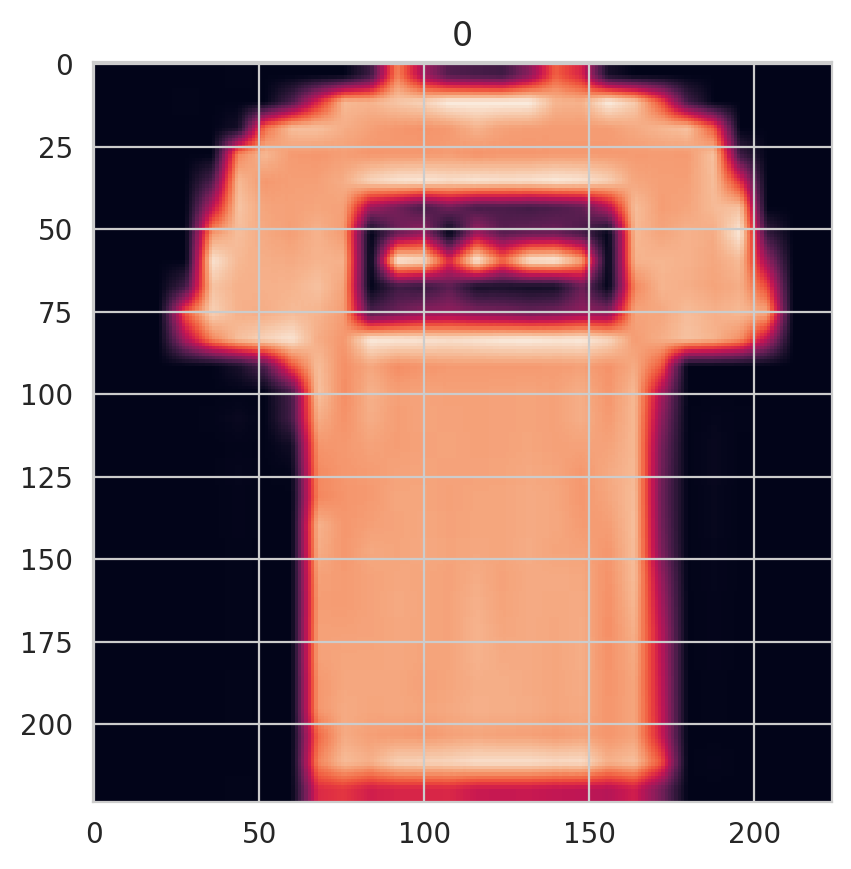

In [ ]:
example_img, example_lbl = train_dataset[1]
plt.imshow(example_img[0])
plt.title(example_lbl)
plt.show()

torch.Size([1, 224, 224])


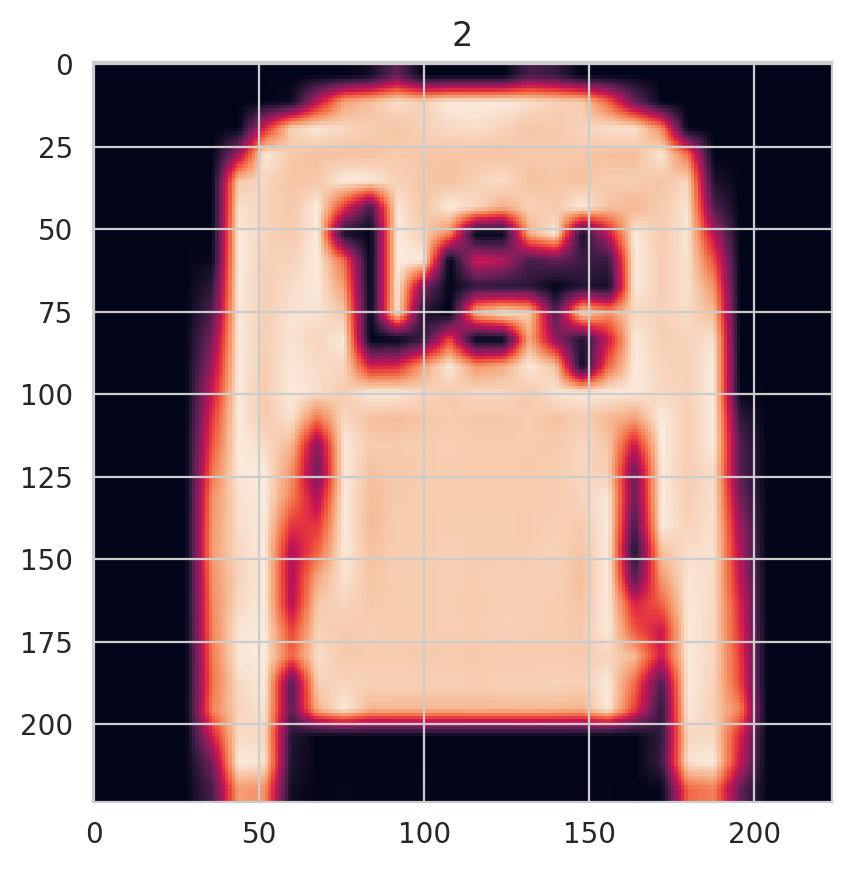

In [ ]:
example_val_img, example_val_lbl = val_dataset[1]
plt.imshow(example_val_img[0])
print(example_val_img.shape)
plt.title(example_val_lbl)
plt.show()

In [ ]:
# i tried to make generalized dataloader
train_dataloader = DataLoader(
    dataset = train_dataset,
    batch_size = TaskConfig.batch_size,
    shuffle = True,
    num_workers = 2,
    pin_memory = True,
)

val_dataloader = DataLoader(
    dataset = val_dataset,
    batch_size = TaskConfig.batch_size,
    shuffle = False,
    num_workers = 2,
    pin_memory = True,
)

In [ ]:
from torch import nn

In [ ]:
class CNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.net = nn.Sequential(
        nn.Conv2d(1,64, kernel_size = (11,11), stride = 4, padding = 2),
        nn.ReLU(inplace = True) , # in place modifies input directly w/o creating separate object --> saving memory
        nn.MaxPool2d(kernel_size = (3,3), stride = 2),

        nn.Conv2d(64, 192, kernel_size = (5,5), stride = 1, padding = 2),
        nn.ReLU(inplace = True),
        nn.MaxPool2d(kernel_size = (3,3), stride = 2),

        nn.Conv2d(192, 384, kernel_size = (3,3), stride = 1, padding = 1),
        nn.ReLU(inplace = True),

        nn.Conv2d(384, 384, kernel_size = (3,3), stride = 1, padding = 1),
        nn.ReLU(inplace = True),

        nn.Conv2d(384, 256, kernel_size = (3,3), stride = 1, padding = 1),
        nn.ReLU(inplace = True),
        nn.MaxPool2d(kernel_size = (3,3), stride = 2),

        nn.AdaptiveAvgPool2d((6, 6)) # to get desired output of size (6,6)

    )
    self.classifier = nn.Sequential(
        nn.Linear(9216, 4096),
        nn.ReLU(inplace = True),
        nn.Dropout(p = 0.5),
        nn.Linear(4096, 1000),
        nn.ReLU(inplace = True),
        nn.Dropout(p = 0.5),
        nn.Linear(1000, TaskConfig.num_classes )
        )



  def forward(self, x):
      x = self.net(x)
      x = x.view(x.size(0), 256 * 6 * 6)
      x = self.classifier(x)

      return x


In [ ]:
criterion = nn.CrossEntropyLoss()

## **Training** **Pipeline**

In [ ]:
from IPython import display
from tqdm.auto import tqdm

In [ ]:
!pip install wandb
import wandb

wandb.login()

wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

In [ ]:
cnn = CNN()
cnn.to(TaskConfig.device)

In [ ]:
optimizer = torch.optim.Adam(cnn.parameters(), lr=TaskConfig.learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TaskConfig.num_epochs * len(train_dataloader), eta_min=1e-4)

In [ ]:
def train_one_epoch(model, criterion, optimizer, dataloader, device, epoch):
  model.train()

  avg_loss = 0
  step = epoch * len(dataloader) # current step
  for batch_idx, (image,label) in tqdm(enumerate(dataloader), total = len(dataloader)):
    image, label = image.to(device), label.to(device)

    output = model(image)
    loss = criterion(output, label)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    scheduler.step()

    avg_loss += loss.item()

    wandb.log({
        "train_step_loss": loss.item(),
        "lr": scheduler.get_last_lr()[0]
    }, step = step + batch_idx)

    if batch_idx == 1:
      wandb.log({"train_image": wandb.Image(image[0])}, step = step + batch_idx)
  avg_loss = avg_loss / (batch_idx+1)

  return avg_loss

In [ ]:
@torch.inference_mode()
def evaluate(model, criterion, dataloader, device):
  model.eval()

  avg_loss = 0
  acc = 0
  total_elems = 0

  for batch_idx, (image, label) in tqdm(enumerate(dataloader), total = len(dataloader)):
    image, label = image.to(device), label.to(device)

    output = model(image)
    loss = criterion(output, label)

    avg_loss += loss.item()

    acc += (output.argmax(dim = -1) == label).sum().item()
    total_elems += output.shape[0]
    avg_loss += loss.item()


  avg_loss = avg_loss / (batch_idx+1)
  acc =  100 * acc / total_elems

  return avg_loss, acc


In [ ]:
def train(model, train_dataloader, val_dataloader, criterion, optimizer, scheduler, device, num_epochs):


  for epoch in range(num_epochs):
    train_avg_loss = train_one_epoch(model, criterion, optimizer, train_dataloader, device,epoch)
    val_avg_loss, val_acc = evaluate(model, criterion, val_dataloader, device)
    wandb.log({
            "train_avg_loss": train_avg_loss, # no need to create lists yourself
            "val_avg_loss": val_avg_loss,
            "val_accuracy": val_acc,
        }, step=(epoch + 1) * len(train_dataloader)) # this is the total number of steps until now



In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu" # "cuda" -- use GPU, "cpu" -- use CPU
print(device)

In [ ]:
!pip install --upgrade wandb

In [ ]:
def _save_checkpoint(self, epoch, save_best=False, only_best=False):
        """
        Save the checkpoints.

        Args:
            epoch (int): current epoch number.
            save_best (bool): if True, rename the saved checkpoint to 'model_best.pth'.
            only_best (bool): if True and the checkpoint is the best, save it only as
                'model_best.pth'(do not duplicate the checkpoint as
                checkpoint-epochEpochNumber.pth)
        """
        arch = type(self.model).__name__
        state = {
            "arch": arch,
            "epoch": epoch,
            "state_dict": self.model.state_dict(),
            "optimizer": self.optimizer.state_dict(),
            "lr_scheduler": self.lr_scheduler.state_dict(),
            "monitor_best": self.mnt_best,
            "config": self.config,
        }
        filename = str(self.checkpoint_dir / f"checkpoint-epoch{epoch}.pth")
        if not (only_best and save_best):
            torch.save(state, filename)
            if self.config.writer.log_checkpoints:
                self.writer.add_checkpoint(filename, str(self.checkpoint_dir.parent))
            self.logger.info(f"Saving checkpoint: {filename} ...")
        if save_best:
            best_path = str(self.checkpoint_dir / "model_best.pth")
            torch.save(state, best_path)
            if self.config.writer.log_checkpoints:
                self.writer.add_checkpoint(best_path, str(self.checkpoint_dir.parent))
            self.logger.info("Saving current best: model_best.pth ...")

In [ ]:
with wandb.init(
    settings=wandb.Settings(start_method="thread"),
    project = "ALEXNET",
    name = "vanila_alex_50_epochs",


) as run:
  train(cnn, train_dataloader, val_dataloader, criterion, optimizer, scheduler, TaskConfig.device, TaskConfig.num_epochs)

        # try:
        #     self.train(cnn, train_dataloader, val_dataloader, criterion, optimizer, scheduler, TaskConfig.device, TaskConfig.num_epochs)
        # except KeyboardInterrupt as e:
        #     self._save_checkpoint(self._last_epoch, save_best=False)
        #     raise e


## **Saving checkpoint in dir**

In [ ]:
def add_checkpoint(self, checkpoint_path, save_dir):
        """
        Log checkpoints to the experiment tracker.

        The checkpoints will be available in the files section
        inside the run_name dir.

        Args:
            checkpoint_path (str): path to the checkpoint file.
            save_dir (str): path to the dir, where checkpoint is saved.
        """
        self.wandb.save(checkpoint_path, base_path=save_dir)
